# Вся работа разбита на несколько этапов:

- EDA 
- Изучение текстов (model_text)
- Работа с эмбеддинами
- Визуализация эмбеддингов
- Кластеризация
- Оценка и интерпретация кластеров
- Применение метода из статьи
- Выводы

## EDA

Датасет состоит из товаров электроники Яндекс Маркета. Всего около 4,8 млн строк, так как работа выполняется локально дальнейшая работа будет проделана с случайно выбранной частью этих данных. Отсюда сразу возникает вопрос - можно ли доверять этим данным? Так как размер выборки состовляет X% от всей и состоит из случайно выбранных строк, а не какого-то среза, в рамках курсовой работы полученным результатам можно доверять.


На этапе EDA изучаются количество товаров, количество категорий, распределение товаров по категориям, структура каталога path, а также общие характеристики данных. Для наглядности строятся графики распределения товаров по категориям и анализа дисбаланса.

Полученные результаты позволяют понять структуру датасета и подготовить данные к дальнейшему анализу текстов и эмбеддингов.

In [118]:
# все импорты проекта
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import pyarrow.dataset as ds
import numpy as np

In [82]:
from pathlib import Path

DATA_PATH = Path("../data/raw/dataset-electronics-5M.parquet")

print("Файл:", DATA_PATH)
print("Размер:", DATA_PATH.stat().st_size, "bytes")

Файл: ../data/raw/dataset-electronics-5M.parquet
Размер: 7599544425 bytes


In [83]:
import pyarrow.parquet as pq

parquet_file = pq.ParquetFile(DATA_PATH)

print("Количество строк:", parquet_file.metadata.num_rows)
print("Количество колонок:", parquet_file.metadata.num_columns)
print("Количество row groups:", parquet_file.num_row_groups)

Количество строк: 4793821
Количество колонок: 5
Количество row groups: 2108


Нас особенно интересует, какого типа embedding. Это определит, как мы будем извлекать эмбеддинги для последующей кластеризации.

После этого посмотрим несколько реальных записей, но возьмём очень маленькую выборку, чтобы не загружать весь датасет. 

In [84]:
# Проверяем структуру Parquet и типы данных
print(parquet_file.schema)

required group field_id=-1 schema {
  required int64 field_id=-1 category_id (Int(bitWidth=64, isSigned=false));
  required binary field_id=-1 embedding;
  required int64 field_id=-1 model_id (Int(bitWidth=64, isSigned=false));
  required binary field_id=-1 model_text;
  required binary field_id=-1 path;
}



embedding хранится в бинарном формате (binary), поэтому перед кластеризацией необходимо восстановить исходные векторы.

То есть embedding хранится не как обычный массив чисел, а как байтовая последовательность. Прежде чем кластеризовать, нам нужно правильно восстановить из этих bytes вектор эмбеддинга.

In [85]:
# Загружаем только первый row group для небольшой проверки
table = parquet_file.read_row_group(0)

print("Количество строк в row group:", table.num_rows)
print("Колонки:", table.column_names)

Количество строк в row group: 3578
Колонки: ['category_id', 'embedding', 'model_id', 'model_text', 'path']


Изучм одну запись:

In [86]:
# Проверяем формат одного embedding
embedding_bytes = table["embedding"][0].as_py()

print("Тип:", type(embedding_bytes))
print("Размер:", len(embedding_bytes), "bytes")
print("Первые 64 bytes:")
print(embedding_bytes[:64].hex())

Тип: <class 'bytes'>
Размер: 3122 bytes
Первые 64 bytes:
5b03000000000000b5bf3b0300000000006076bf3b03000000000040b4bf3b030000000000a0973f3b030000000000c07d3f3b030000000000a0c3bf3b030000


In [87]:
# Берём первый embedding из первого row group
embedding_bytes = table["embedding"][0].as_py()

print("Тип:", type(embedding_bytes))
print("Размер:", len(embedding_bytes), "bytes")
print("Первые 64 bytes:")
print(embedding_bytes[:64].hex())

Тип: <class 'bytes'>
Размер: 3122 bytes
Первые 64 bytes:
5b03000000000000b5bf3b0300000000006076bf3b03000000000040b4bf3b030000000000a0973f3b030000000000c07d3f3b030000000000a0c3bf3b030000


In [88]:
# Проверяем, одинаковый ли размер имеют embeddings
lengths = [
    len(table["embedding"][i].as_py())
    for i in range(min(100, table.num_rows))
]

print("Уникальные размеры:", sorted(set(lengths)))

Уникальные размеры: [3122]


Убедились, что эмбеддинги бинарные и имеют фиксированный размер, декодирование будет проведено этольно перед этапом кластеризации.

Смотрим сами данные

In [89]:
# Получаем только category_id для всего датасета
category_data = parquet_file.read(
    columns=["category_id"]
).to_pandas()

print("Всего товаров:", len(category_data))

Всего товаров: 4793821


In [90]:
sample_fraction = 480_000 / len(category_data)

sample_indices = (
    category_data
    .groupby("category_id", group_keys=False)
    .sample(
        frac=sample_fraction,
        random_state=42
    )
    .index
)

print("Размер выборки:", len(sample_indices))

Размер выборки: 480003


In [91]:
sample = parquet_file.read(
    columns=[
        "category_id",
        "model_id",
        "model_text",
        "path"
    ]
).to_pandas()

sample = sample.iloc[sample_indices]

print("Размер выборки:", sample.shape)

Размер выборки: (480003, 4)


In [92]:
sample.memory_usage(deep=True).sum() / 1024**3

np.float64(1.0099384151399136)

Мы используем row groups, потому что датасет большой — 4793821 товаров и 7599544425 bytes. Загружать всё сразу в память нерационально, особенно учитывая, что внутри ещё хранятся эмбеддинги. Поэтому будем брать данные частями и обрабатывать их постепенно. Это позволит спокойно работать с датасетом на ноутбуке и не упираться в ограничение по оперативной памяти.

Проверяем пропуски - их нет

In [93]:
sample.isna().sum()

category_id    0
model_id       0
model_text     0
path           0
dtype: int64

Уникальнось

In [94]:
print("Всего товаров:", len(sample))
print("Уникальных model_id:", sample["model_id"].nunique())
print("Уникальных текстов:", sample["model_text"].nunique())
print("Уникальных категорий:", sample["category_id"].nunique())
print("Уникальных путей:", sample["path"].nunique())

Всего товаров: 480003
Уникальных model_id: 480003
Уникальных текстов: 444560
Уникальных категорий: 122
Уникальных путей: 122


Дубликаты

In [95]:
duplicate_count = sample["model_text"].duplicated().sum()

print("Дубликатов model_text:", duplicate_count)
print(
    "Доля дубликатов:",
    duplicate_count / len(sample) * 100,
    "%"
)

Дубликатов model_text: 35443
Доля дубликатов: 7.383912183882184 %


In [96]:
# В выборке обнаружено 35 443 повторяющихся текстовых описания,
# что составляет 7.38% строк.
# Это не обязательно означает дублирование самих товаров:
# разные товары могут иметь одинаковое текстовое описание.

Теперь изучим категории

In [97]:
sample["path"] = sample["path"].str.decode("utf-8")  # декодируем path

In [98]:
category_stats = (

    sample["category_id"]

    .value_counts()

    .rename_axis("category_id")

    .reset_index(name="product_count")

)

category_paths = (

    sample[["category_id", "path"]]

    .drop_duplicates("category_id")

)

category_stats = category_stats.merge(

    category_paths,

    on="category_id",

    how="left"

)

category_stats["category_name"] = (
    category_stats["path"]
    .str.replace("Все товары/Электроника/", "", regex=False)
    .str.replace("Все товары/Авто/Электроника/", "", regex=False)
)

category_stats[
    ["category_id", "category_name", "product_count"]
].head(20)

,category_id,category_name,product_count
0,91072,Телефоны/Аксессуары для телефонов/Защитные пле...,100803
1,14960839,Игровые приставки и аксессуары/Игры для приста...,43437
2,91499,Телефоны/Аксессуары для телефонов/Запчасти для...,40192
3,90555,Портативная техника/Наушники и гарнитуры,21809
4,15876896,"Телефоны/Аксессуары для телефонов/Штативы, дер...",18588
5,91491,Телефоны/Мобильные телефоны,17442
6,91503,Телефоны/Аксессуары для телефонов/Зарядные уст...,15815
7,13939151,Телефоны/Ремешки для умных часов,15671
8,186461,Игровые приставки и аксессуары/Аксессуары,13141
9,10498025,Телефоны/Умные часы и браслеты,12206


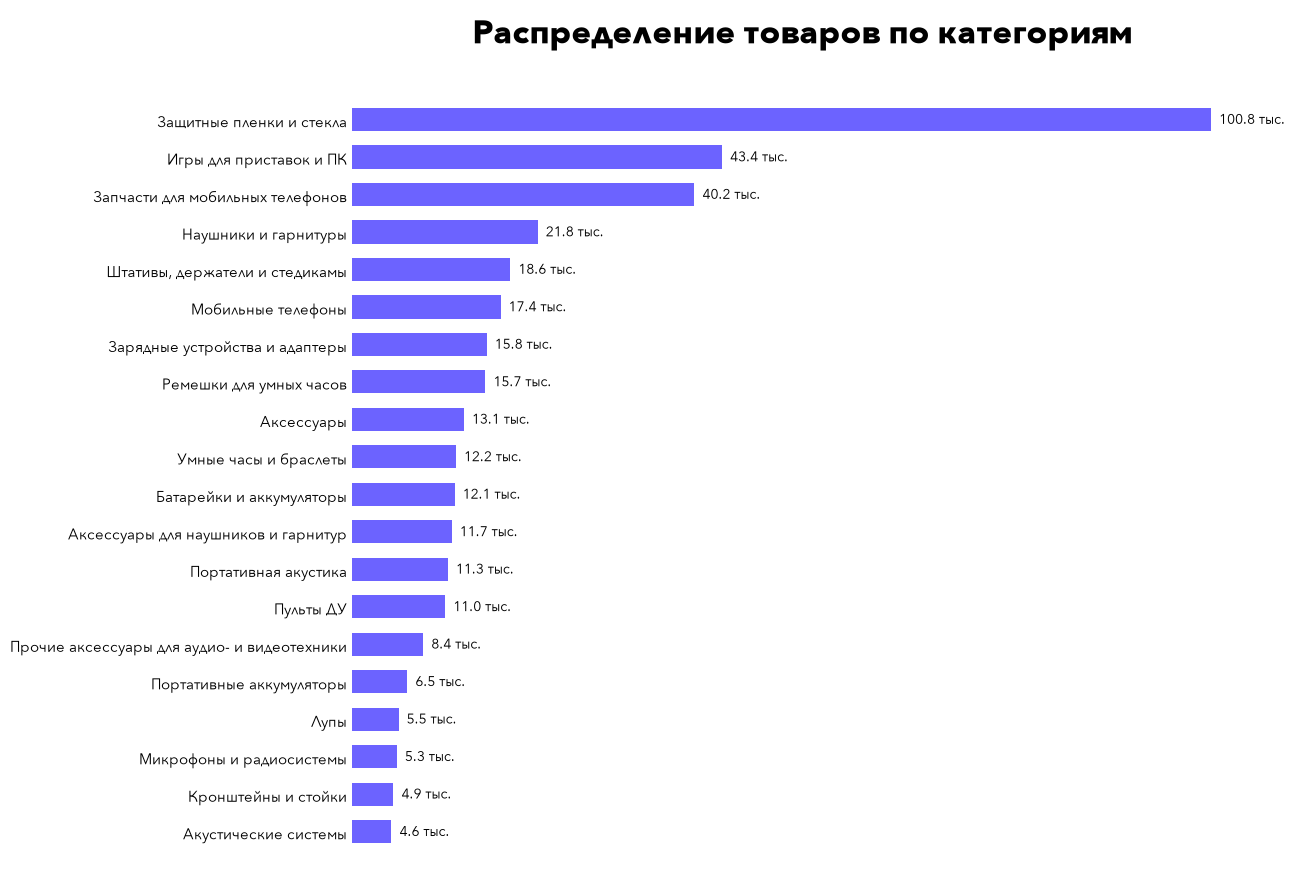

In [99]:
import matplotlib.pyplot as plt

top_categories = category_stats.head(20).copy()

top_categories["category_name"] = (
    top_categories["category_name"]
    .str.split("/")
    .str[-1]
)

plt.figure(figsize=(13, 9))

bars = plt.barh(
    top_categories["category_name"],
    top_categories["product_count"],
    height=0.62,
    color="#6C63FF"
)

plt.title(
    "Распределение товаров по категориям",
    loc="center",
    fontsize=24,
    fontname="Avenir Next",
    fontweight="bold",
    pad=20
)

plt.xlabel("")
plt.ylabel("")

plt.xticks([])
plt.yticks(
    fontsize=11,
    fontname="Avenir Next"
)

plt.grid(False)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

plt.tick_params(axis="y", length=0)
plt.tick_params(axis="x", length=0)

for bar, value in zip(bars, top_categories["product_count"]):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"  {value / 1000:.1f} тыс.",
        va="center",
        fontsize=10,
        fontname="Avenir Next"
    )

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [100]:
median_category_size = category_stats["product_count"].median()
largest_category_size = category_stats["product_count"].max()

print(f"Медианная категория: {median_category_size:,.0f} товаров")
print(f"Крупнейшая категория: {largest_category_size:,.0f} товаров")
print(
    f"Крупнейшая категория больше медианной в "
    f"{largest_category_size / median_category_size:.1f} раза"
)

Медианная категория: 849 товаров
Крупнейшая категория: 100,803 товаров
Крупнейшая категория больше медианной в 118.7 раза


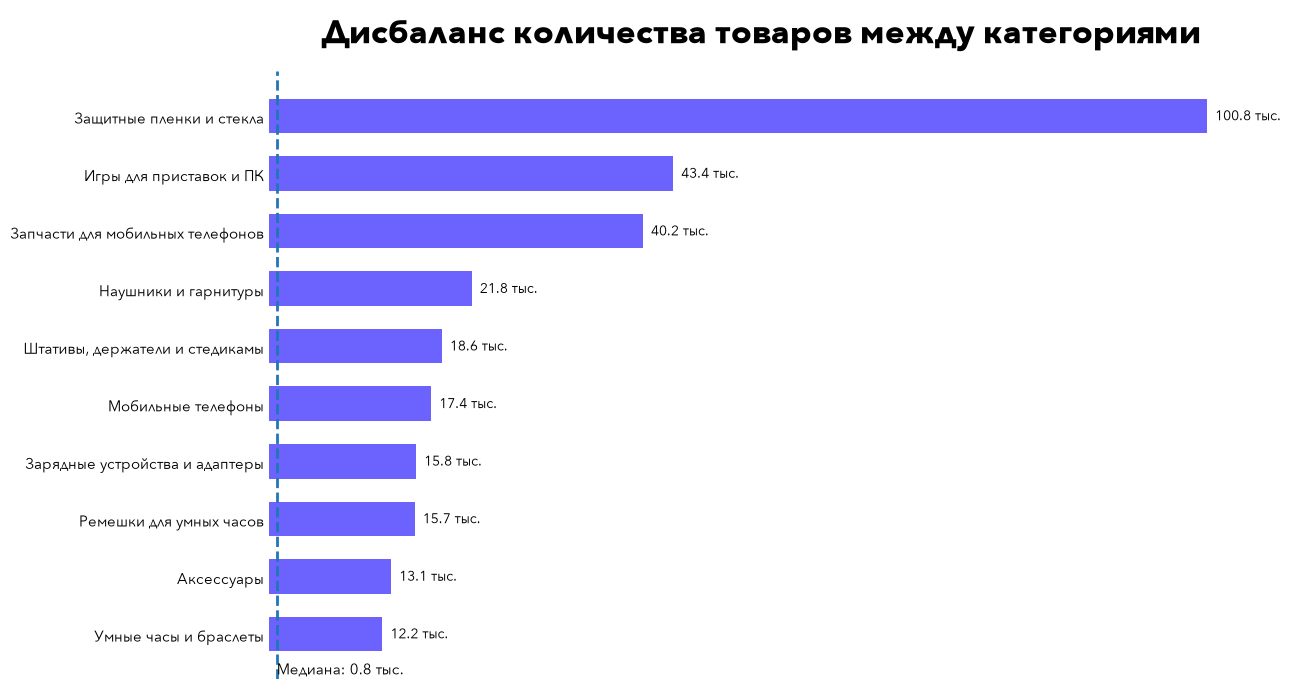

In [101]:
import matplotlib.pyplot as plt

top_categories = category_stats.head(10).copy()

top_categories["category_name"] = (
    top_categories["category_name"]
    .str.split("/")
    .str[-1]
)

plt.figure(figsize=(13, 7))

bars = plt.barh(
    top_categories["category_name"],
    top_categories["product_count"],
    height=0.6,
    color="#6C63FF"
)

plt.axvline(
    median_category_size,
    linewidth=2,
    linestyle="--"
)

plt.text(
    median_category_size,
    len(top_categories) - 0.2,
    f"Медиана: {median_category_size / 1000:.1f} тыс.",
    fontsize=11,
    fontname="Avenir Next",
    va="bottom"
)

plt.title(
    "Дисбаланс количества товаров между категориями",
    fontsize=24,
    fontname="Avenir Next",
    fontweight="bold",
    pad=20
)

plt.xlabel("")
plt.ylabel("")

plt.xticks([])
plt.yticks(
    fontsize=11,
    fontname="Avenir Next"
)

plt.grid(False)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

plt.tick_params(axis="y", length=0)
plt.tick_params(axis="x", length=0)

for bar, value in zip(
    bars,
    top_categories["product_count"]
):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"  {value / 1000:.1f} тыс.",
        va="center",
        fontsize=10,
        fontname="Avenir Next"
    )

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Распределение товаров по категориям оказалось сильно неравномерным. Медианная категория содержит 849 товаров, тогда как крупнейшая — 100 803 товара, то есть почти в 119 раз больше. Такой дисбаланс необходимо учитывать при дальнейшей кластеризации и особенно при интерпретации полученных результатов, поскольку крупные категории представлены в данных значительно сильнее небольших.

### Анализ текстов

Дальше логично перейти к анализу model_text, потому что именно текст лежит в основе наших эмбеддингов.

In [102]:
sample["model_text"] = sample["model_text"].str.decode("utf-8")

In [103]:
sample[
    ["category_id", "model_id", "model_text", "path"]
].sample(
    10,
    random_state=42
)

,category_id,model_id,model_text,path
3755475,8353924,4469960807,Портативное солнечное зарядное устройство 40Вт...,Все товары/Электроника/Телефоны/Аксессуары для...
3075003,90627,102299234906,Пульт Huayu Polar HTR-D18AНе определенПульт Hu...,Все товары/Электроника/Аудио- и видеотехника/А...
2616491,15876896,4430233646,"Игрушка Годжо Сатору с качающейся головой, гол...",Все товары/Электроника/Телефоны/Аксессуары для...
2533282,91072,4506456483,Защитная виниловая броня / пленка / бронеплёнк...,Все товары/Электроника/Телефоны/Аксессуары для...
4116896,14960839,103729342620,Remnant: From the Ashes PS4 & PS5SonyНЕ являет...,Все товары/Электроника/Игровые приставки и акс...
1578645,2501051,4635723495,Крепление устройств умного домаНе определенИсп...,Все товары/Электроника/Портативная техника/Сис...
2954102,91503,4320778084,Зарядное устройство для аккумуляторов USB 4.8V...,Все товары/Электроника/Телефоны/Аксессуары для...
3811085,91072,102909438314,Комплект 3шт. Защитная гидрогелевая антишпион ...,Все товары/Электроника/Телефоны/Аксессуары для...
2460649,91072,103491946930,Гидрогелевая пленка для телефона матовая для A...,Все товары/Электроника/Телефоны/Аксессуары для...
972447,91499,103650934496,Полифонический динамик с пластиком Honor X5 Pl...,Все товары/Электроника/Телефоны/Аксессуары для...


In [104]:
sample["model_text"].sample(
    1,
).to_list()

['NEYPO / Защитное Стекло на весь экран для Huawei Honor 7A/ 7S/ Y5 Lite 2018/ Y5 Prime 2018NeypoСтекло Full Glue полностью повторяет форму дисплея с обрамлением под цвет смартфона и практически незаметно на экране. У данного вида стекол слой клея нанесён по всей поверхности, что гарантирует максимальную плотность прилегания стекла к телефону и обеспечивает высокую чувствительность дисплея. <br /><br />Стекло имеет олеофобное покрытие, благодаря которому оно отталкивает капли влаги, частички грязи, пыли, жира и в результате экран смартфона меньше пачкается даже при самом активном использовании. <br /><br />Благодаря специальной термической обработке ударопрочность стекла к внешним воздействиям увеличена в разы, а значит, при механическом повреждении оно не рассыпается на мелкие кусочки и исключает возможность получить царапины и ссадины из-за осколков. <br /><br />В комплекте со стеклом есть влажная и сухая салфетки, стикер для удавления частиц пыли. <br /><br />Стекло защитит ваш смар

In [105]:
text_stats = sample["model_text"].str.len()

print(f"Минимальная длина: {text_stats.min()}")
print(f"Средняя длина: {text_stats.mean():.1f}")
print(f"Медианная длина: {text_stats.median():.1f}")
print(f"Максимальная длина: {text_stats.max()}")

Минимальная длина: 7
Средняя длина: 1174.6
Медианная длина: 1127.0
Максимальная длина: 6438


In [106]:
print(
    text_stats.quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

0.01      41.0
0.05      80.0
0.25     586.0
0.50    1127.0
0.75    1623.0
0.95    2498.0
0.99    3923.0
Name: model_text, dtype: float64


Тексты товаров достаточно информативны: медианная длина описания составляет 1127 символов. При этом наблюдается заметный разброс: встречаются как очень короткие описания длиной менее 50 символов, так и длинные описания более 6000 символов. Большая часть текстов находится в диапазоне от нескольких сотен до примерно 2500 символов.

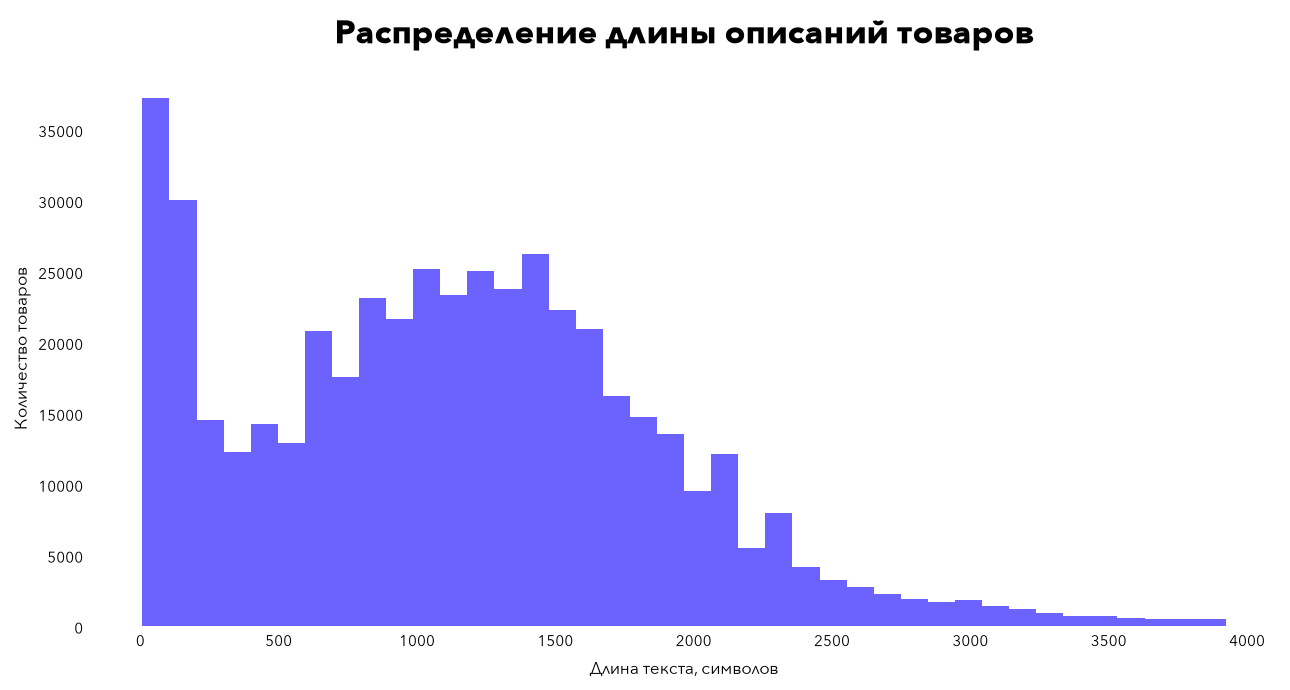

In [107]:
import matplotlib.pyplot as plt

p99 = text_stats.quantile(0.99)

plt.figure(figsize=(13, 7))

plt.hist(
    text_stats[text_stats <= p99],
    bins=40,
    color="#6C63FF"
)

plt.title(
    "Распределение длины описаний товаров",
    fontsize=24,
    fontname="Avenir Next",
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Длина текста, символов",
    fontsize=12,
    fontname="Avenir Next"
)

plt.ylabel(
    "Количество товаров",
    fontsize=12,
    fontname="Avenir Next"
)

plt.xticks(
    fontsize=11,
    fontname="Avenir Next"
)

plt.yticks(
    fontsize=11,
    fontname="Avenir Next"
)

plt.grid(False)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

plt.tick_params(axis="both", length=0)

plt.tight_layout()
plt.show()

In [108]:
short_text_stats = pd.DataFrame({
    "Порог": ["< 50", "< 100", "< 200", "< 500"],
    "Количество": [
        (text_stats < 50).sum(),
        (text_stats < 100).sum(),
        (text_stats < 200).sum(),
        (text_stats < 500).sum()
    ]
})

short_text_stats["Доля, %"] = (
    short_text_stats["Количество"] / len(text_stats) * 100
)

short_text_stats

,Порог,Количество,"Доля, %"
0,< 50,7667,1.597282
1,< 100,34702,7.229538
2,< 200,66732,13.902413
3,< 500,108713,22.648400


In [109]:
sample.loc[
    text_stats.nsmallest(20).index,
    ["model_text", "category_id", "path"]
]

,model_text,category_id,path
451064,Картаt2,13371306,Все товары/Электроника/Телефоны/Тарифные планы...
451093,Картаt2,13371306,Все товары/Электроника/Телефоны/Тарифные планы...
450935,Картаt2,13371306,Все товары/Электроника/Телефоны/Тарифные планы...
451001,Картаt2,13371306,Все товары/Электроника/Телефоны/Тарифные планы...
451160,Картаt2,13371306,Все товары/Электроника/Телефоны/Тарифные планы...
3674307,FiiO K7Fiio,90554,Все товары/Электроника/Аудио- и видеотехника/А...
2891106,НаушникиJBL,90555,Все товары/Электроника/Портативная техника/Нау...
1526825,ВспышкаSams,90617,Все товары/Электроника/Фото и видеокамеры/Фото...
1526695,ВспышкаSams,90617,Все товары/Электроника/Фото и видеокамеры/Фото...
1526693,ВспышкаSams,90617,Все товары/Электроника/Фото и видеокамеры/Фото...


Анализ длины текстов показал, что около 22.6% описаний содержат менее 500 символов. При этом проверка наиболее коротких записей показала, что они в основном представляют собой краткие названия товаров, а не явно некорректные данные. Поэтому на этапе подготовки данных такие записи не исключались.

In [110]:
length_bins = pd.cut(
    text_stats,
    bins=[0, 100, 500, 1000, 2000, 3000, float("inf")],
    labels=[
        "до 100",
        "100–500",
        "500–1000",
        "1000–2000",
        "2000–3000",
        "3000+"
    ]
)

length_stats = (
    length_bins
    .value_counts(sort=False)
    .rename_axis("length_range")
    .reset_index(name="product_count")
)

length_stats["share"] = (
    length_stats["product_count"]
    / len(text_stats)
    * 100
)

length_stats

,length_range,product_count,share
0,до 100,35208,7.334954
1,100–500,73616,15.336571
2,500–1000,100040,20.841536
3,1000–2000,210368,43.826393
4,2000–3000,48045,10.009312
5,3000+,12726,2.651233


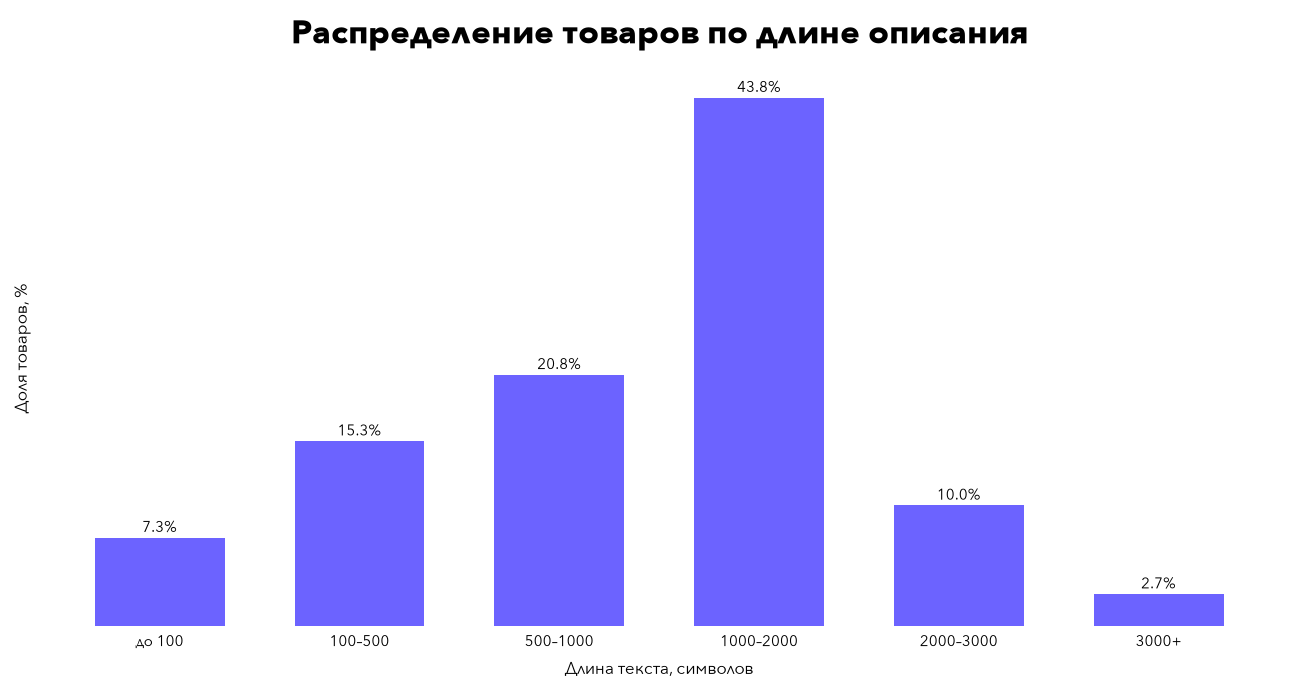

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 7))

bars = plt.bar(
    length_stats["length_range"],
    length_stats["share"],
    width=0.65,
    color="#6C63FF"
)

plt.title(
    "Распределение товаров по длине описания",
    fontsize=24,
    fontname="Avenir Next",
    fontweight="bold",
    pad=20
)

plt.xlabel(
    "Длина текста, символов",
    fontsize=12,
    fontname="Avenir Next"
)

plt.ylabel(
    "Доля товаров, %",
    fontsize=12,
    fontname="Avenir Next"
)

plt.xticks(
    fontsize=11,
    fontname="Avenir Next"
)

plt.yticks([])

plt.grid(False)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

plt.tick_params(axis="both", length=0)

for bar, value in zip(bars, length_stats["share"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontname="Avenir Next"
    )

plt.tight_layout()
plt.show()

### Вывод по EDA

* Датасет содержит 4,79 млн товаров и 122 категории.
* Распределение товаров по категориям сильно неравномерное: крупнейшая категория больше медианной примерно в 119 раз.
* model_text содержит подробные описания товаров. Медианная длина текста — 1127 символов.
* Около 65% текстов имеют длину от 500 до 2000 символов.
* 7,38% текстов являются дубликатами.
* Короткие описания в основном являются названиями реальных товаров, поэтому удалять их не будем.

Итог: данные подходят для дальнейшего анализа текстовых представлений. Следующий этап — исследование и подготовка эмбеддингов для кластеризации.


## Анализ текста



In [112]:
print("Количество текстов:", len(sample))
print("Пропусков:", sample["model_text"].isna().sum())
print("Дубликатов:", sample["model_text"].duplicated().sum())

Количество текстов: 480003
Пропусков: 0
Дубликатов: 35443


In [113]:
import re

text_data = sample["model_text"].str.replace(
    r"<[^>]+>",
    " ",
    regex=True
)

text_data = (
    text_data
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

text_data.head()

1690957    Радар-детектор TDS TS-CAR36TDSДисплей: есть Ти...
1707311    Радар-детектор Street Storm STR-7100EXT GP Two...
1706162    Набор автолюбителю подарочныйБез брендаНапомин...
1705263    SILVER STONE 6925300000250 SILVERSTONE F1 HYBR...
1706962    Кабель питания для радар-детекторов Neoline X-...
Name: model_text, dtype: str

In [80]:

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(text_data)

print("Размер TF-IDF:", X_tfidf.shape)
print("Количество ненулевых значений:", X_tfidf.nnz)

Размер TF-IDF: (480003, 5000)
Количество ненулевых значений: 44873335


In [121]:
duplicate_categories = (
    sample
    .groupby("model_text")["category_id"]
    .nunique()
)

cross_category_duplicates = duplicate_categories[
    duplicate_categories > 1
]

print(
    "Уникальных текстов, встречающихся в нескольких категориях:",
    len(cross_category_duplicates)
)

print(
    "Доля таких текстов:",
    round(
        len(cross_category_duplicates) / sample["model_text"].nunique() * 100,
        2
    ),
    "%"
)

Уникальных текстов, встречающихся в нескольких категориях: 423
Доля таких текстов: 0.1 %


In [122]:
examples = (
    sample[
        sample["model_text"].isin(
            cross_category_duplicates.index
        )
    ]
    .sort_values("model_text")
)

examples[
    ["model_text", "category_id", "path"]
].head(20)

,model_text,category_id,path
741491,(1x) Для Samsung Galaxy Fit 3 зарядный кабель ...,91503,Все товары/Электроника/Телефоны/Аксессуары для...
4454869,(1x) Для Samsung Galaxy Fit 3 зарядный кабель ...,16265381,Все товары/Электроника/Телефоны/Аксессуары для...
1779927,(G O F M)Карта для видеоигр N8 SUPERGAME PRO 2...,91122,Все товары/Электроника/Игровые приставки и акс...
1763122,(G O F M)Карта для видеоигр N8 SUPERGAME PRO 2...,91122,Все товары/Электроника/Игровые приставки и акс...
4037913,(G O F M)Карта для видеоигр N8 SUPERGAME PRO 2...,186461,Все товары/Электроника/Игровые приставки и акс...
759855,"1 комплект из 4 пар, PB2 PB3 наушники силиконо...",90555,Все товары/Электроника/Портативная техника/Нау...
3525426,"1 комплект из 4 пар, PB2 PB3 наушники силиконо...",16265387,Все товары/Электроника/Портативная техника/Акс...
1858879,"1 комплект, версия T21PD, зарядное устройство ...",8353924,Все товары/Электроника/Телефоны/Аксессуары для...
414782,"1 комплект, версия T21PD, зарядное устройство ...",14946301,Все товары/Электроника/Аудио- и видеотехника/А...
2310183,"1 пара адаптеров Nab Hub, металлическое основа...",7152189,Все товары/Электроника/Аудио- и видеотехника/А...


Вывод по анализу текстовых данных

В выборке отсутствуют пропуски в текстовых описаниях. Медианная длина текста составляет 1127 символов, при этом основная часть описаний имеет длину от 500 до 2000 символов. Около 7,38% текстов являются дубликатами, однако только 0,1% уникальных текстов встречаются в нескольких категориях.

Тексты содержат не только названия товаров, но и бренды, технические характеристики и описания свойств продукции. Таким образом, model_text содержит достаточно информативные признаки для построения векторных представлений товаров и последующей кластеризации. Следующим этапом является анализ и проверка имеющихся эмбеддингов.